In [2]:
"""Import the model"""
from adtof.model.model import Model

model, hparams = Model.modelFactory(modelName="Frame_RNN", scenario="adtofAll", fold=0)
assert "peakThreshold" in hparams
assert model.weightLoadedFlag

In [3]:
print(hparams)
print(model)

{'diff': False, 'context': 9, 'labelOffset': 0, 'samePadding': True, 'learningRate': 0.0005, 'validation_epoch': 4, 'training_epoch': 2, 'batchSize': 32, 'multiplePPThreshold': True, 'GRU_units': [60, 60, 60], 'n_channels': 1, 'conv_Filter': [32, 64], 'regulateSamplingProbability': 0.7, 'peakThreshold': [0.22000000000000003, 0.24000000000000002, 0.32000000000000006, 0.22000000000000003, 0.30000000000000004], 'labels': [35, 38, 47, 42, 49], 'sampleWeight': array([1.07800015, 1.35310867, 3.41372305, 1.14427696, 1.76755104]), 'emptyWeight': 1, 'sampleRate': 100, 'samplePerTrack': 1, 'trainingSequence': 412, 'labelRadiation': 1, 'normalize': False, 'architecture': 'CRNN', 'fmin': 20, 'fmax': 20000, 'bandsPerOctave': 12, 'reduce_patience': 10, 'stopping_patience': 25}


In [9]:
"""Transcribe any audio file."""

# Change the paths according to your configuration
# use raw strings (or double backslashes) to avoid unicode‑escape errors
audioFiles = r"C:\Users\rsanc\Documents\Proyectos\ADTOF\test_audio\Borivers_90BPM_012.wav"
outputLocation = r"C:\Users\rsanc\Documents\Proyectos\ADTOF\test_output"
model.predictFolder(audioFiles, outputLocation, **hparams)


c:\Users\rsanc\miniconda3\envs\adtof\lib\site-packages\madmom\io\audio.py:643: WavFileWarning: Chunk (non-data) not understood, skipping it.
  file_sample_rate, signal = wavfile.read(filename, mmap=True)


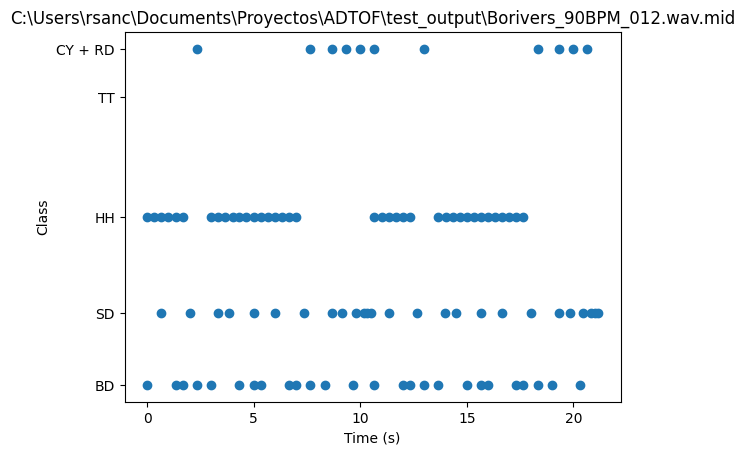

In [10]:
"""plot the estimated transcription"""
import pretty_midi
import glob
import matplotlib.pyplot as plt

for file in glob.glob(outputLocation+"/*.mid"):
    transcription = pretty_midi.PrettyMIDI(file)
    plt.scatter([note.start for note in transcription.instruments[0].notes], [note.pitch for note in transcription.instruments[0].notes])
    plt.yticks([35, 38, 42, 47, 49], ["BD", "SD", "HH", "TT", "CY + RD"])
    plt.title(file)
    plt.xlabel("Time (s)")
    plt.ylabel("Class")
    plt.show()
    break